**KELOMPOK 5**

Nama Anggota :
 1.  Natasya Nur Aqillah 24.11.6008
 2.  Cahya Restu Pertiwi 24.11.6035
3. Ilham Khalik 24.11.6220
4.  Sidiq Doyo Atmojo 24.11.6010
5. Riski Andika Setianto 24.11.6032



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')


In [ ]:
try:
    df = pd.read_csv('dataset_tech_skills_clean.csv', sep=';')
    print("Dataset berhasil dimuat!")
except FileNotFoundError:
    print("Error: File 'dataset_tech_skills_clean.csv' tidak ditemukan. Pastikan sudah di-upload ke Colab.")

Dataset berhasil dimuat!


In [ ]:
df_clean = df.dropna(subset=['Gaji_Clean']).copy()
skill_cols = [col for col in df.columns if col.startswith('Skill_')]

In [ ]:
print("\n" + "="*40 + "\n--- A. EDA & VISUALISASI DATA ---\n" + "="*40)


--- A. EDA & VISUALISASI DATA ---


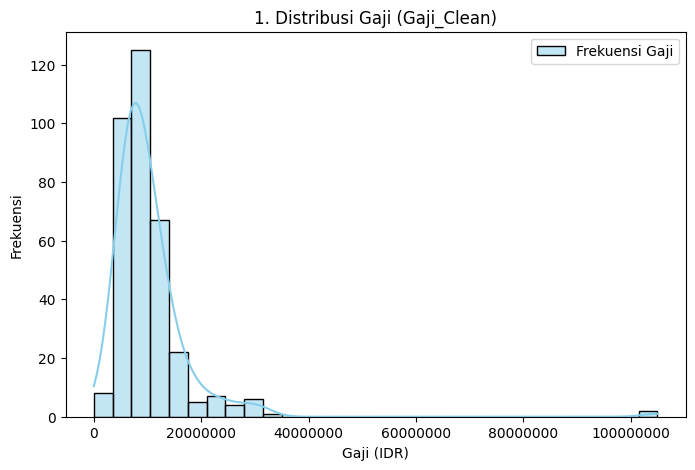

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df_clean['Gaji_Clean'], bins=30, kde=True, color='skyblue', label='Frekuensi Gaji')
plt.title('1. Distribusi Gaji (Gaji_Clean)')
plt.xlabel('Gaji (IDR)')
plt.ylabel('Frekuensi')
plt.ticklabel_format(style='plain', axis='x')
plt.legend()
plt.show()

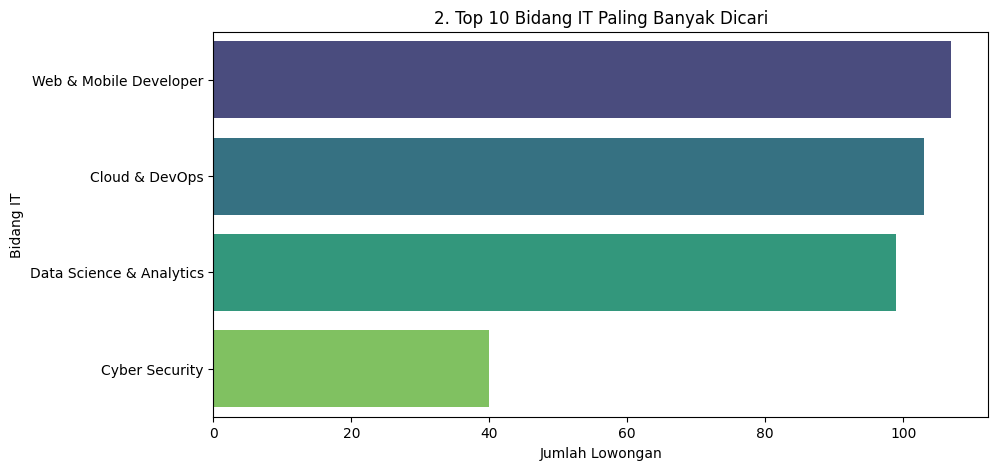

In [ ]:
plt.figure(figsize=(10, 5))
top_jobs = df_clean['Bidang_IT'].value_counts().head(10)
sns.barplot(y=top_jobs.index, x=top_jobs.values, palette='viridis')
plt.title('2. Top 10 Bidang IT Paling Banyak Dicari')
plt.xlabel('Jumlah Lowongan')
plt.ylabel('Bidang IT')
plt.show()


In [ ]:
print("\n" + "="*40 + "\n--- B. ANALISIS KORELASI ---\n" + "="*40)
df_corr = df_clean[skill_cols + ['Gaji_Clean']]
korelasi = df_corr.corr()


--- B. ANALISIS KORELASI ---


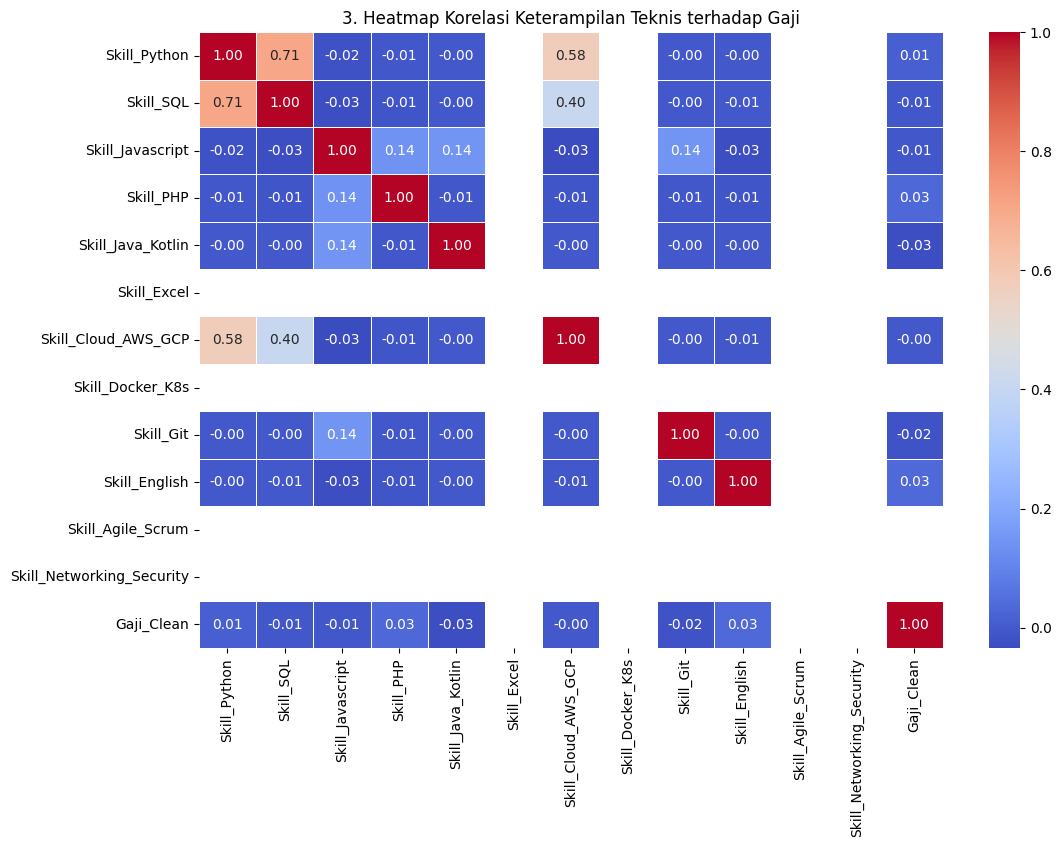

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(korelasi, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('3. Heatmap Korelasi Keterampilan Teknis terhadap Gaji')
plt.show()

In [ ]:

print("\n" + "="*40 + "\n--- C. PEMBUATAN MODEL REGRESI LINIER ---\n" + "="*40)



--- C. PEMBUATAN MODEL REGRESI LINIER ---


In [ ]:
X = df_clean[skill_cols]
y = df_clean['Gaji_Clean']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)
print("Model Regresi Linier Berganda berhasil dilatih!")

Model Regresi Linier Berganda berhasil dilatih!


In [ ]:
print("\n" + "="*40 + "\n--- D. EVALUASI MODEL ---\n" + "="*40)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE) : Rp {mae:,.2f}")
print(f"Root Mean Squared Error (RMSE) : Rp {rmse:,.2f}")
print(f"R-squared (R2) Score : {r2:.4f}")


--- D. EVALUASI MODEL ---
Mean Absolute Error (MAE) : Rp 5,067,343.65
Root Mean Squared Error (RMSE) : Rp 6,855,563.57
R-squared (R2) Score : -0.0306


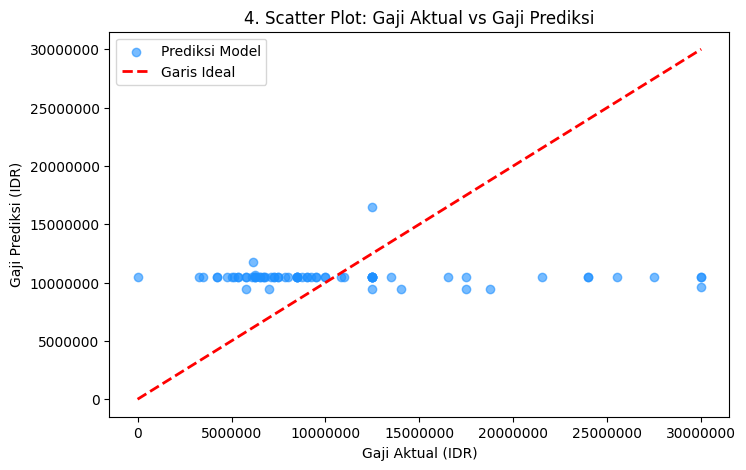

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.6, color='dodgerblue', label='Prediksi Model')

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Garis Ideal')

plt.title('4. Scatter Plot: Gaji Aktual vs Gaji Prediksi')
plt.xlabel('Gaji Aktual (IDR)')
plt.ylabel('Gaji Prediksi (IDR)')
plt.ticklabel_format(style='plain', axis='both')
plt.legend()
plt.show()


In [ ]:
print("\n" + "="*40 + "\n--- E. UJI ASUMSI KLASIK ---\n" + "="*40)
residuals = y_test - y_pred



--- E. UJI ASUMSI KLASIK ---


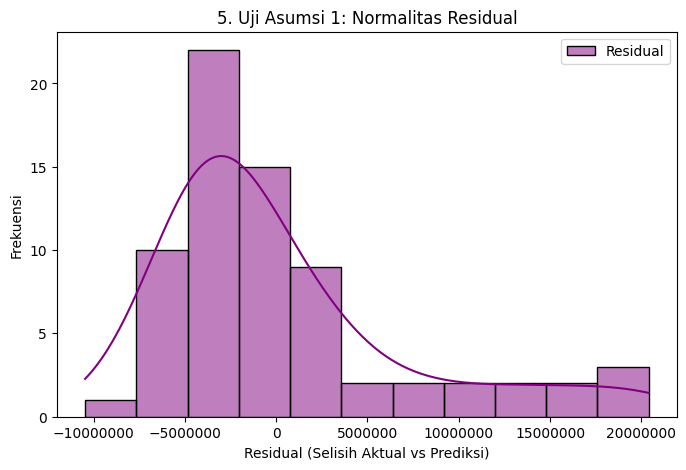

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True, color='purple', label='Residual')
plt.title('5. Uji Asumsi 1: Normalitas Residual')
plt.xlabel('Residual (Selisih Aktual vs Prediksi)')
plt.ylabel('Frekuensi')
plt.ticklabel_format(style='plain', axis='x')
plt.legend()
plt.show()

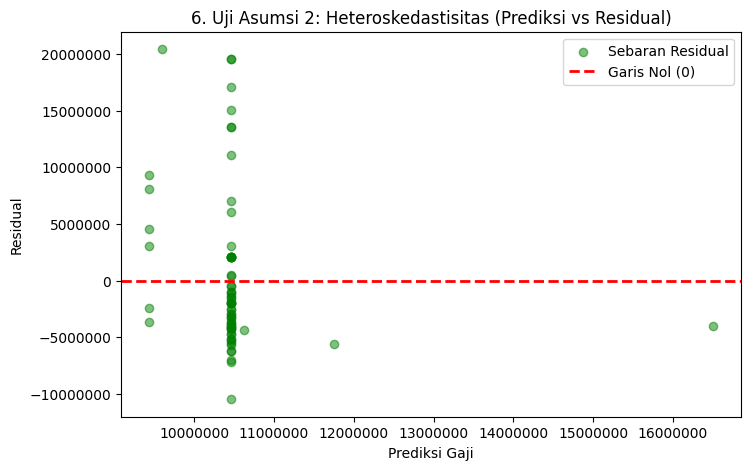

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.5, color='green', label='Sebaran Residual')
plt.axhline(y=0, color='red', linestyle='--', lw=2, label='Garis Nol (0)')
plt.title('6. Uji Asumsi 2: Heteroskedastisitas (Prediksi vs Residual)')
plt.xlabel('Prediksi Gaji')
plt.ylabel('Residual')
plt.ticklabel_format(style='plain', axis='both')
plt.legend()
plt.show()

In [ ]:
X_active = X.loc[:, X.var() > 0]
X_vif = sm.add_constant(X_active)

vif_data = pd.DataFrame()
vif_data["Fitur (Skill)"] = X_vif.columns
vif_data["Nilai VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

print("Hasil Uji Asumsi 3: Multikolinearitas (VIF)\n")
print(vif_data[vif_data['Fitur (Skill)'] != 'const'].sort_values(by='Nilai VIF', ascending=False).to_string(index=False))
print("\n*Catatan: Nilai VIF < 10 mengindikasikan TIDAK ADA multikolinearitas yang serius.")

Hasil Uji Asumsi 3: Multikolinearitas (VIF)

      Fitur (Skill)  Nilai VIF
       Skill_Python   2.496176
          Skill_SQL   1.995197
Skill_Cloud_AWS_GCP   1.497065
   Skill_Javascript   1.067313
          Skill_Git   1.022897
  Skill_Java_Kotlin   1.022897
          Skill_PHP   1.020494
      Skill_English   1.000928

*Catatan: Nilai VIF < 10 mengindikasikan TIDAK ADA multikolinearitas yang serius.
